# ☀️ Solar Panel Defect Classification — Deep Learning Pipeline

**Pipeline phases:**
1. Environment Setup (secrets, MLflow/DagsHub, MongoDB)
2. Dataset Upload & Extraction
3. Data Loading & EDA
4. Baseline CNN Model
5. Improved CNN (BatchNorm + Dropout + Augmentation)
6. Transfer Learning — MobileNetV2
7. Transfer Learning — EfficientNetB0
8. Hyperparameter Tuning (Keras Tuner)
9. Final Model Training & MLflow Logging
10. Model Evaluation & Saving
11. Streamlit App Save
12. Final Zip & Download

> **Runtime:** GPU (T4 or A100 recommended)  
> **Dataset:** Upload your zip file when prompted in Phase 2

---
## Phase 0 — Install Dependencies

In [1]:
# Install all required packages in one shot
# keras-tuner: hyperparameter search
# dagshub + mlflow: experiment tracking
# pymongo: MongoDB logging
# streamlit: inference app
!pip install -q keras-tuner dagshub mlflow pymongo streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147

---
## Phase 1 — Environment & Secrets Setup

In [2]:
import os
from google.colab import userdata

# ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# ── MLflow / DagsHub ──────────────────────────────────────────────────────────
USE_DAGSHUB = True  # set False to log locally inside Colab

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow — logs saved inside Colab session
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('✅ Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

✅ Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


In [3]:
# ── Global project config ─────────────────────────────────────────────────────
# All paths and hyperparameter defaults live here so nothing is hard-coded below

# Paths
PROJECT_ROOT   = "/content/solar_panel_project"
DATASET_DIR    = os.path.join(PROJECT_ROOT, "dataset")
OUTPUTS_DIR    = os.path.join(PROJECT_ROOT, "outputs")
MODELS_DIR     = os.path.join(OUTPUTS_DIR,  "models")
PLOTS_DIR      = os.path.join(OUTPUTS_DIR,  "plots")
APP_DIR        = os.path.join(PROJECT_ROOT, "app")

# Image / training params
IMG_HEIGHT  = 224
IMG_WIDTH   = 224
BATCH_SIZE  = 32
SEED        = 42
VAL_SPLIT   = 0.2

# MLflow experiment name
EXPERIMENT_NAME = "solar_panel_defect_classification"

# Create all directories upfront
for d in [PROJECT_ROOT, DATASET_DIR, OUTPUTS_DIR, MODELS_DIR, PLOTS_DIR, APP_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Directory structure created:")
for d in [PROJECT_ROOT, DATASET_DIR, OUTPUTS_DIR, MODELS_DIR, PLOTS_DIR, APP_DIR]:
    print(f"   {d}")

✅ Directory structure created:
   /content/solar_panel_project
   /content/solar_panel_project/dataset
   /content/solar_panel_project/outputs
   /content/solar_panel_project/outputs/models
   /content/solar_panel_project/outputs/plots
   /content/solar_panel_project/app


---
## Phase 2 — Dataset Upload & Extraction

In [ ]:
import zipfile
import shutil
from google.colab import drive

# ── Mount Google Drive ────────────────────────────────────────────────────────
# Upload your dataset zip to your Google Drive first, then update ZIP_PATH below.
# Example: if you put it at "My Drive/solar_dataset.zip" →
#          ZIP_PATH = "/content/drive/MyDrive/solar_dataset.zip"

drive.mount("/content/drive", force_remount=False)

ZIP_PATH = "/content/drive/MyDrive/solar_dataset.zip"   # <── UPDATE THIS PATH

def extract_dataset(zip_path: str, extract_to: str) -> str:
    """
    Extracts the dataset zip file to extract_to.
    Handles single-folder zips by flattening one level.
    Returns the path to the extracted dataset directory.
    """
    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"Zip not found at: {zip_path}\n"
            "Please upload your dataset zip to Google Drive and update ZIP_PATH above."
        )

    print(f"🔍 Extracting '{zip_path}' → {extract_to}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)

    # If the zip created a single top-level folder, move its contents up
    contents = os.listdir(extract_to)
    if len(contents) == 1 and os.path.isdir(os.path.join(extract_to, contents[0])):
        inner = os.path.join(extract_to, contents[0])
        for item in os.listdir(inner):
            shutil.move(os.path.join(inner, item), extract_to)
        os.rmdir(inner)

    class_dirs = [d for d in os.listdir(extract_to)
                  if os.path.isdir(os.path.join(extract_to, d))]
    print(f"\n✅ Extraction complete. Found {len(class_dirs)} class folders:")
    for c in sorted(class_dirs):
        n = len(os.listdir(os.path.join(extract_to, c)))
        print(f"   {c}: {n} images")

    return extract_to


DATASET_DIR = extract_dataset(ZIP_PATH, DATASET_DIR)


In [5]:
import os
import zipfile
import shutil

# ── Local ZIP already uploaded in Colab ───────────────────────────────────────
# Your dataset zip is stored at:
ZIP_PATH = "/content/Data.zip"

def extract_dataset(zip_path: str, extract_to: str) -> str:
    """
    Extracts the dataset zip file to extract_to.
    Handles single-folder zips by flattening one level.
    Returns the path to the extracted dataset directory.
    """
    if not os.path.exists(zip_path):
        raise FileNotFoundError(
            f"Zip not found at: {zip_path}\n"
            "Please confirm the file exists in /content/."
        )

    # Create extraction directory if needed
    os.makedirs(extract_to, exist_ok=True)

    print(f"🔍 Extracting '{zip_path}' → {extract_to}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)

    # If the zip created a single top-level folder, flatten it
    contents = os.listdir(extract_to)
    if len(contents) == 1 and os.path.isdir(os.path.join(extract_to, contents[0])):
        inner = os.path.join(extract_to, contents[0])

        print(f"📂 Flattening nested folder: {contents[0]}")
        for item in os.listdir(inner):
            shutil.move(os.path.join(inner, item), extract_to)

        os.rmdir(inner)

    # Detect class folders
    class_dirs = [
        d for d in os.listdir(extract_to)
        if os.path.isdir(os.path.join(extract_to, d))
    ]

    print(f"\n✅ Extraction complete. Found {len(class_dirs)} class folders:")
    for c in sorted(class_dirs):
        n = len(os.listdir(os.path.join(extract_to, c)))
        print(f"   {c}: {n} images")

    return extract_to


# ── Set extraction destination ────────────────────────────────────────────────
DATASET_DIR = "/content/solar_panel_project/dataset"

# ── Run extraction ────────────────────────────────────────────────────────────
DATASET_DIR = extract_dataset(ZIP_PATH, DATASET_DIR)

🔍 Extracting '/content/Data.zip' → /content/solar_panel_project/dataset
📂 Flattening nested folder: Data

✅ Extraction complete. Found 6 class folders:
   Bird-drop: 193 images
   Clean: 194 images
   Dusty: 190 images
   Electrical-damage: 103 images
   Physical-Damage: 69 images
   Snow-Covered: 123 images


---
## Phase 3 — Imports & Data Loading

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import pickle

import tensorflow as tf
from tensorflow.keras.layers import (
    RandomFlip, RandomRotation, RandomZoom,
    Rescaling, Conv2D, BatchNormalization,
    MaxPooling2D, Flatten, Dropout, Dense,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input as effnet_preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess_input

import mlflow
import mlflow.keras

print(f"✅ TensorFlow version : {tf.__version__}")
print(f"   MLflow version     : {mlflow.__version__}")
print(f"   GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow version : 2.20.0
   MLflow version     : 3.11.1
   GPU available      : True


In [8]:
def load_datasets(dataset_dir: str,
                  img_height: int,
                  img_width: int,
                  batch_size: int,
                  val_split: float,
                  seed: int):
    """
    Load train and validation tf.data.Dataset objects from a directory.
    Returns (train_ds, val_ds, class_names).
    """
    AUTOTUNE = tf.data.AUTOTUNE

    common_kwargs = dict(
        directory        = dataset_dir,
        validation_split = val_split,
        image_size       = (img_height, img_width),
        batch_size       = batch_size,
        seed             = seed,
    )
    # Get class_names before any transformations
    raw_train_ds = tf.keras.utils.image_dataset_from_directory(
        subset="training", **common_kwargs
    )
    class_names = raw_train_ds.class_names

    train_ds = raw_train_ds
    val_ds = tf.keras.utils.image_dataset_from_directory(
        subset="validation", **common_kwargs
    )

    # Cast labels to int32 (prevents silent float-cast bug with sparse_categorical_crossentropy)
    def cast_labels(img, lbl):
        return img, tf.cast(lbl, tf.int32)

    train_ds = train_ds.map(cast_labels, num_parallel_calls=AUTOTUNE)
    val_ds   = val_ds.map(cast_labels,   num_parallel_calls=AUTOTUNE)

    # Cache + prefetch for performance (critical for GPU utilisation)
    train_ds = train_ds.cache().shuffle(1000, seed=seed).prefetch(AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, class_names


def compute_class_weights(dataset_dir: str, class_names: list) -> dict:
    """
    Compute inverse-frequency class weights to handle class imbalance.
    Returns a dict {class_index: weight}.
    """
    counts = {}
    total  = 0
    for name in class_names:
        n = len(os.listdir(os.path.join(dataset_dir, name)))
        counts[name] = n
        total += n

    n_classes = len(class_names)
    weights   = {}
    for idx, name in enumerate(class_names):
        weights[idx] = total / (n_classes * counts[name])
    return weights


# ── Load data ─────────────────────────────────────────────────────────────────
train_ds, val_ds, CLASS_NAMES = load_datasets(
    DATASET_DIR, IMG_HEIGHT, IMG_WIDTH, BATCH_SIZE, VAL_SPLIT, SEED
)
NUM_CLASSES   = len(CLASS_NAMES)
CLASS_WEIGHTS = compute_class_weights(DATASET_DIR, CLASS_NAMES)

print(f"\n✅ Datasets loaded")
print(f"   Classes ({NUM_CLASSES}) : {CLASS_NAMES}")
print(f"   Class weights          : {CLASS_WEIGHTS}")

# Save class names for reference by the app later
with open(os.path.join(OUTPUTS_DIR, "class_names.json"), "w") as f:
    json.dump(CLASS_NAMES, f)
print("   class_names.json saved ✅")

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.

✅ Datasets loaded
   Classes (6) : ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
   Class weights          : {0: 0.7530224525043178, 1: 0.7491408934707904, 2: 0.7649122807017544, 3: 1.4110032362459546, 4: 2.106280193236715, 5: 1.1815718157181572}
   class_names.json saved ✅


In [9]:
# ── Sanity check: verify data pipeline before any training ───────────────────
print("🔎 Pipeline sanity check...")

for images, labels in train_ds.take(1):
    print(f"   Image batch shape : {images.shape}")
    print(f"   Image dtype       : {images.dtype}")
    print(f"   Image range       : [{images.numpy().min():.1f}, {images.numpy().max():.1f}]")
    print(f"   Label batch shape : {labels.shape}")
    print(f"   Label dtype       : {labels.dtype}")
    print(f"   Label range       : [{labels.numpy().min()}, {labels.numpy().max()}]")
    unique_labels = set(labels.numpy().tolist())
    print(f"   Unique labels in 1st batch: {sorted(unique_labels)}")
    assert labels.dtype == tf.int32, f"Labels must be int32, got {labels.dtype}"
    assert images.dtype == tf.float32, f"Images must be float32, got {images.dtype}"
    expected = set(range(NUM_CLASSES))
    # At least some classes should appear; warn if only 1 class in first batch
    if len(unique_labels) == 1:
        print("   ⚠️  Only 1 class in first batch — check dataset directory structure!")
    else:
        print(f"   ✅ {len(unique_labels)} classes visible in first batch")

print("\n✅ Sanity check passed — pipeline is ready for training.")


🔎 Pipeline sanity check...
   Image batch shape : (32, 224, 224, 3)
   Image dtype       : <dtype: 'float32'>
   Image range       : [0.0, 255.0]
   Label batch shape : (32,)
   Label dtype       : <dtype: 'int32'>
   Label range       : [0, 5]
   Unique labels in 1st batch: [0, 1, 2, 3, 4, 5]
   ✅ 6 classes visible in first batch

✅ Sanity check passed — pipeline is ready for training.


---
## Phase 3b — Exploratory Data Analysis

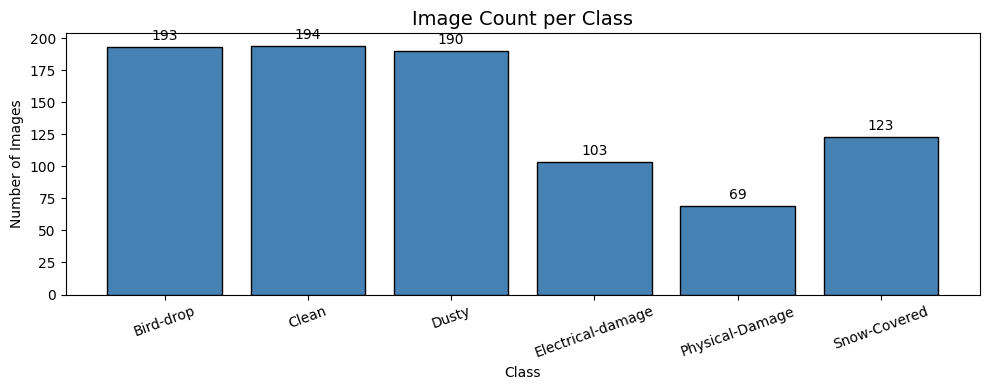

   Plot saved → /content/solar_panel_project/outputs/plots/class_distribution.png


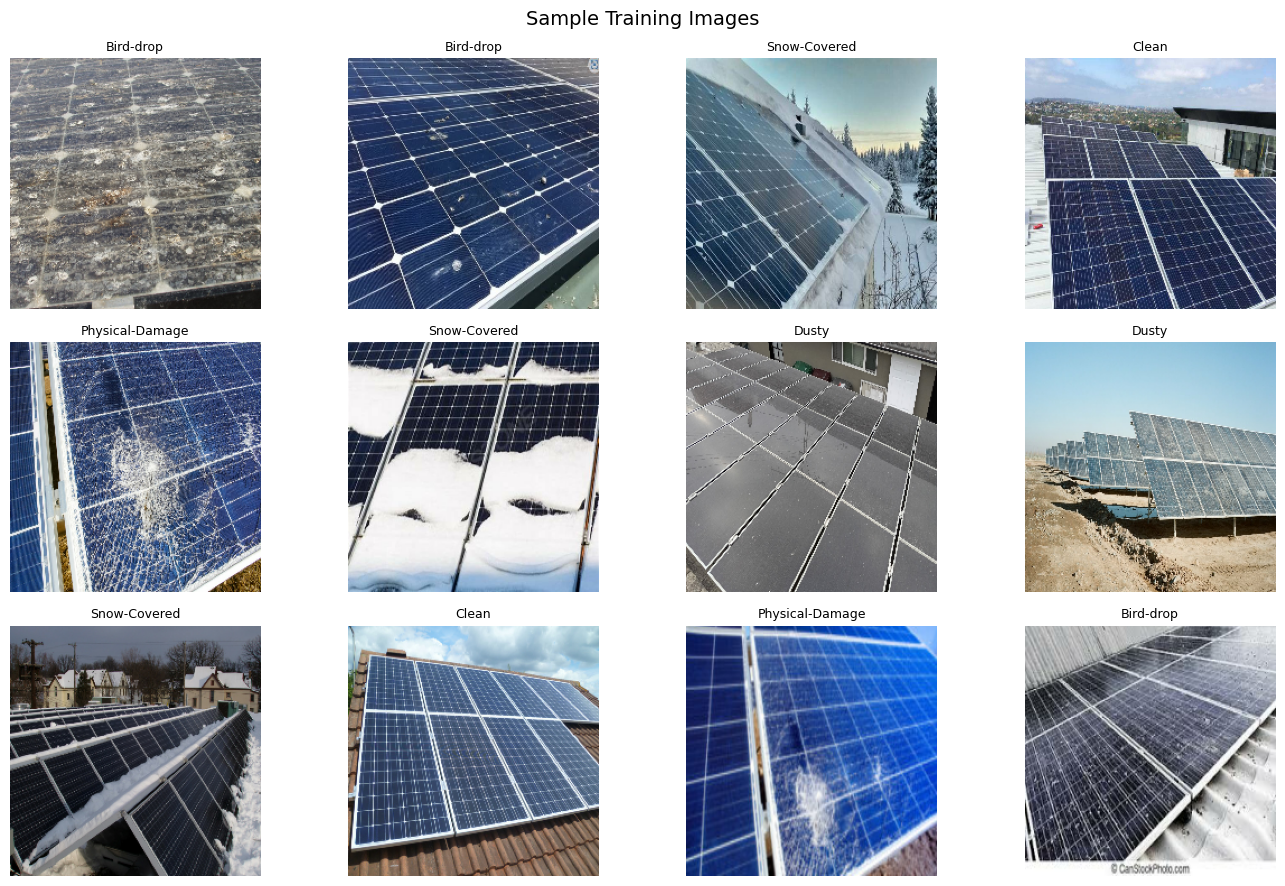

   Plot saved → /content/solar_panel_project/outputs/plots/sample_images.png


In [10]:
def plot_class_distribution(dataset_dir: str, class_names: list, save_path: str):
    """
    Bar chart showing image count per class.
    Saved to save_path so it persists between phases.
    """
    counts = [
        len(os.listdir(os.path.join(dataset_dir, c)))
        for c in class_names
    ]
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(class_names, counts, color='steelblue', edgecolor='black')
    ax.bar_label(bars, padding=3)
    ax.set_title("Image Count per Class", fontsize=14)
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Images")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"   Plot saved → {save_path}")


def plot_sample_images(train_ds, class_names: list, save_path: str, n: int = 12):
    """
    Display a grid of sample training images with class labels.
    """
    images, labels = next(iter(train_ds))
    rows = (n + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(14, rows * 3))
    for i, ax in enumerate(axes.flat):
        if i >= n:
            ax.axis('off')
            continue
        ax.imshow(images[i].numpy().astype('uint8'))
        ax.set_title(class_names[labels[i].numpy()], fontsize=9)
        ax.axis('off')
    plt.suptitle("Sample Training Images", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"   Plot saved → {save_path}")


# Run EDA
plot_class_distribution(
    DATASET_DIR, CLASS_NAMES,
    os.path.join(PLOTS_DIR, "class_distribution.png")
)
plot_sample_images(
    train_ds, CLASS_NAMES,
    os.path.join(PLOTS_DIR, "sample_images.png")
)

---
## Phase 4 — Baseline CNN Model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Training Baseline CNN (10 epochs)...
Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 409ms/step - accuracy: 0.2218 - loss: 1.9251 - val_accuracy: 0.2034 - val_loss: 1.7009
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3164 - loss: 1.6412 - val_accuracy: 0.3390 - val_loss: 1.6552
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4675 - loss: 1.3885 - val_accuracy: 0.4294 - val_loss: 1.4969
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5876 - loss: 1.1739 - val_accuracy: 0.5198 - val_loss: 1.2764
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6794 - loss: 0.9053 - val_accuracy: 0.6328 - val_loss: 1.1978
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7288 - loss: 0.7480 - val_accuracy: 0.5311 - val_loss: 1.3061
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8319 - loss: 0.5010 - val_accuracy: 0.5706 - val_loss: 1.3907
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9082

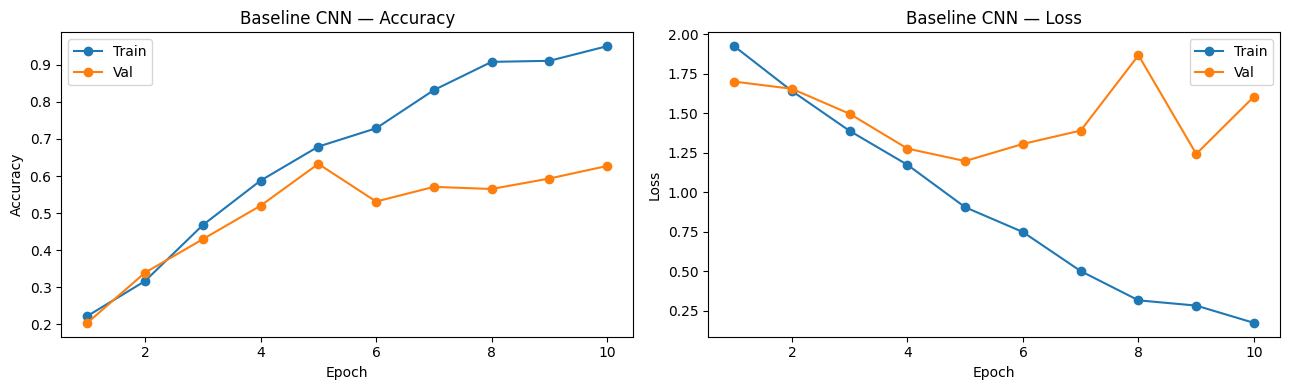

   Plot saved → /content/solar_panel_project/outputs/plots/baseline_cnn_history.png
✅ Baseline phase complete.


In [11]:
def build_baseline_cnn(img_h: int, img_w: int, num_classes: int) -> tf.keras.Model:
    """
    Simple 3-block CNN as a reference baseline.
    Rescaling is baked into the model so raw [0,255] images can be fed directly.
    """
    model = tf.keras.models.Sequential([
        # Normalise to [0, 1]
        Rescaling(1.0 / 255, input_shape=(img_h, img_w, 3)),

        # Conv block 1
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Conv block 2
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        # Conv block 3
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax'),
    ], name="baseline_cnn")

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def plot_training_history(history, title: str, save_path: str):
    """
    Plot accuracy and loss curves for a training run.
    Both subplots are saved to save_path.
    """
    epochs = range(1, len(history.history['accuracy']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Accuracy
    ax1.plot(epochs, history.history['accuracy'],     marker='o', label='Train')
    ax1.plot(epochs, history.history['val_accuracy'], marker='o', label='Val')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss
    ax2.plot(epochs, history.history['loss'],     marker='o', label='Train')
    ax2.plot(epochs, history.history['val_loss'], marker='o', label='Val')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"   Plot saved → {save_path}")


# ── Build & train ─────────────────────────────────────────────────────────────
baseline_model = build_baseline_cnn(IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES)
baseline_model.summary()

print("\n🚀 Training Baseline CNN (10 epochs)...")
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Plot and persist training curves
plot_training_history(
    baseline_history,
    "Baseline CNN",
    os.path.join(PLOTS_DIR, "baseline_cnn_history.png")
)

# Save baseline history for later comparison
with open(os.path.join(OUTPUTS_DIR, "baseline_history.pkl"), "wb") as f:
    pickle.dump(baseline_history.history, f)
print("✅ Baseline phase complete.")

---
## Phase 5 — Improved CNN (BatchNorm + Dropout + Augmentation)

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    25,690,36

 Total params: 26,014,374 (99.24 MB)

 Trainable params: 26,012,710 (99.23 MB)

 Non-trainable params: 1,664 (6.50 KB)


🚀 Training Improved CNN (up to 50 epochs with early stopping)...
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 427ms/step - accuracy: 0.3037 - loss: 3.0572 - val_accuracy: 0.0904 - val_loss: 4.1701 - learning_rate: 3.0000e-04
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 294ms/step - accuracy: 0.3729 - loss: 2.6679 - val_accuracy: 0.0904 - val_loss: 4.0412 - learning_rate: 3.0000e-04
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.4195 - loss: 2.6212 - val_accuracy: 0.0904 - val_loss: 5.8251 - learning_rate: 3.0000e-04
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.4251 - loss: 2.5768 - val_accuracy: 0.0904 - val_loss: 11.0324 - learning_rate: 3.0000e-04
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.4471 - loss: 2.4195
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 289ms/step - accuracy: 0.4534 - loss: 2.4440 - val_accuracy: 0.0904 - val_loss: 13.9719 - learning_rate: 3.0000e-04


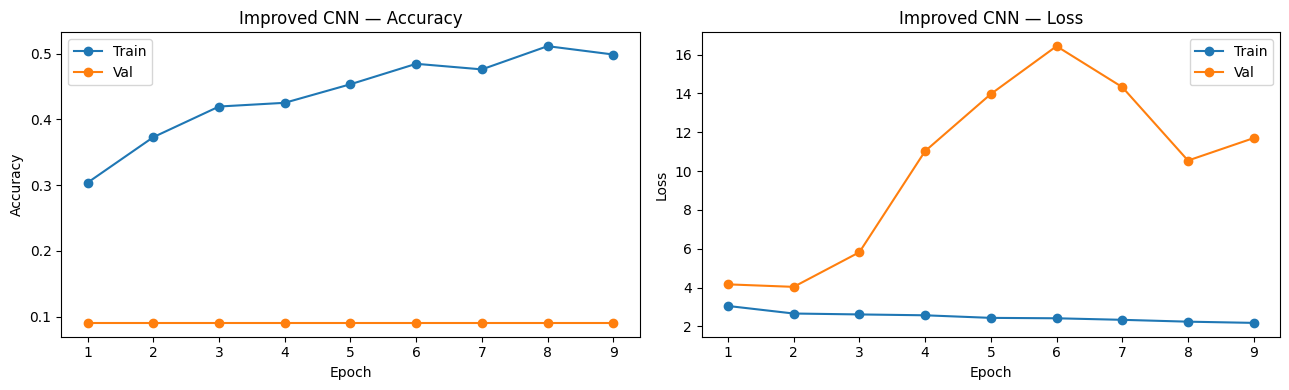

   Plot saved → /content/solar_panel_project/outputs/plots/improved_cnn_history.png

Best val accuracy: 0.0904
✅ Improved CNN phase complete.


In [12]:
def build_improved_cnn(img_h: int, img_w: int, num_classes: int) -> tf.keras.Model:
    """
    Regularised CNN: BatchNorm, Dropout, data augmentation, L2 regularisation,
    and two dense layers.  Targets overfitting seen in the baseline.
    """
    # Augmentation sub-model (only active during training)
    augment = tf.keras.Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.15),
        RandomZoom(0.15),
    ], name="augmentation")

    model = tf.keras.models.Sequential([
        Input(shape=(img_h, img_w, 3)),
        augment,
        Rescaling(1.0 / 255),

        # Conv block 1 — two Conv layers for richer feature extraction
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Conv block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Conv block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.35),

        Flatten(),

        # Dense block with L2 regularisation to penalise large weights
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),

        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),

        Dense(num_classes, activation='softmax'),
    ], name="improved_cnn")

    model.compile(
        # Lower LR than default Adam (1e-3) for more stable convergence
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── Callbacks shared across several training phases ───────────────────────────
def make_callbacks():
    """
    Returns a list of standard training callbacks:
    - EarlyStopping: stops when val_loss stops improving (patience=7)
    - ReduceLROnPlateau: halves LR after 3 stale epochs
    """
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
    ]


# ── Build & train ─────────────────────────────────────────────────────────────
improved_model = build_improved_cnn(IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES)
improved_model.summary()

print("\n🚀 Training Improved CNN (up to 50 epochs with early stopping)...")
improved_history = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=make_callbacks(),
    class_weight=CLASS_WEIGHTS,
)

plot_training_history(
    improved_history,
    "Improved CNN",
    os.path.join(PLOTS_DIR, "improved_cnn_history.png")
)

with open(os.path.join(OUTPUTS_DIR, "improved_cnn_history.pkl"), "wb") as f:
    pickle.dump(improved_history.history, f)

print(f"\nBest val accuracy: {max(improved_history.history['val_accuracy']):.4f}")
print("✅ Improved CNN phase complete.")

---
## Phase 6 — Transfer Learning: MobileNetV2

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocess (Lambda) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


🚀 Training MobileNetV2 (20 epochs)...
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.5014 - loss: 1.2972 - val_accuracy: 0.6102 - val_loss: 0.9591
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7203 - loss: 0.7545 - val_accuracy: 0.7119 - val_loss: 0.8429
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8037 - loss: 0.5508 - val_accuracy: 0.7006 - val_loss: 0.7672
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.7938 - loss: 0.5004 - val_accuracy: 0.7175 - val_loss: 0.7202
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.8475 - loss: 0.3837 - val_accuracy: 0.7571 - val_loss: 0.6596
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8644 - loss: 0.3849 - val_accuracy: 0.7062 - val_loss: 0.7386
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8686 - loss: 0.3715 - val_accuracy: 0.7571 - val_loss: 0.6564
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8644 

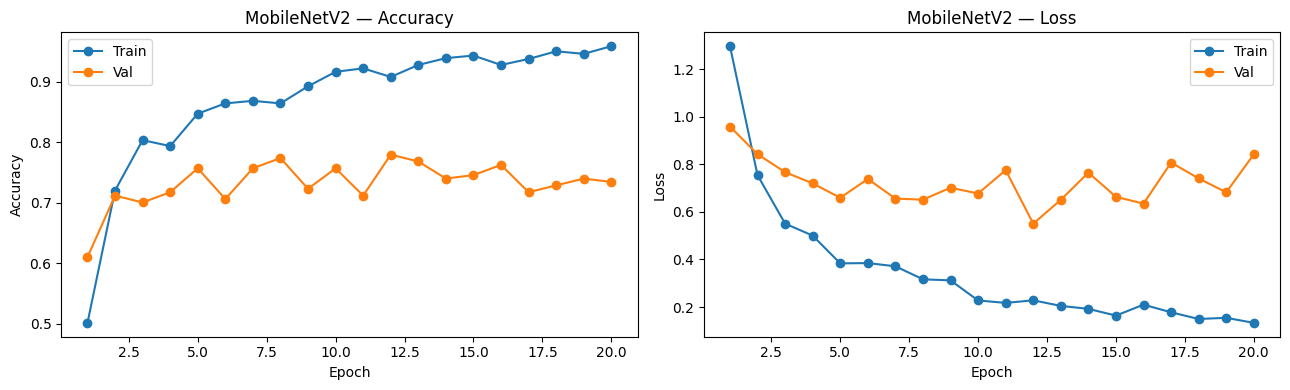

   Plot saved → /content/solar_panel_project/outputs/plots/mobilenetv2_history.png
✅ MobileNetV2 saved → /content/solar_panel_project/outputs/models/mobilenetv2.h5


In [13]:
def build_mobilenetv2(img_h: int, img_w: int, num_classes: int) -> tf.keras.Model:
    """
    MobileNetV2 backbone (frozen) + custom classification head.
    Augmentation is applied before the backbone.
    Rescaling is included so raw [0,255] images are accepted.
    """
    augment = tf.keras.Sequential([
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.1),
    ])

    # Load pre-trained ImageNet weights; freeze to preserve learned features
    base = tf.keras.applications.MobileNetV2(
        input_shape=(img_h, img_w, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    # MobileNetV2 preprocess_input expects [0,255] → scales to [-1,1] internally
    preprocess_layer = tf.keras.layers.Lambda(
        lambda x: mobilenet_preprocess_input(x),
        name="mobilenetv2_preprocess"
    )

    model = tf.keras.models.Sequential([
        Input(shape=(img_h, img_w, 3)),
        augment,
        preprocess_layer,
        base,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax'),
    ], name="mobilenetv2_transfer")

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


mobilenet_model = build_mobilenetv2(IMG_HEIGHT, IMG_WIDTH, NUM_CLASSES)
mobilenet_model.summary()

print("\n🚀 Training MobileNetV2 (20 epochs)...")
mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=CLASS_WEIGHTS,
)

plot_training_history(
    mobilenet_history,
    "MobileNetV2",
    os.path.join(PLOTS_DIR, "mobilenetv2_history.png")
)

# Save the MobileNetV2 model checkpoint
mobilenet_path = os.path.join(MODELS_DIR, "mobilenetv2.h5")
mobilenet_model.save(mobilenet_path)
print(f"✅ MobileNetV2 saved → {mobilenet_path}")

---
## Phase 7 — Transfer Learning: EfficientNetB0

⏳ Preprocessing datasets for EfficientNet...
   train: (708, 224, 224, 3)  val: (177, 224, 224, 3)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


🚀 Training EfficientNetB0 (15 epochs)...
Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.5014 - loss: 1.3041 - val_accuracy: 0.6667 - val_loss: 0.9073
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6977 - loss: 0.8101 - val_accuracy: 0.7062 - val_loss: 0.7516
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.7260 - loss: 0.6737 - val_accuracy: 0.7571 - val_loss: 0.6873
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8037 - loss: 0.5365 - val_accuracy: 0.7627 - val_loss: 0.6555
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.7966 - loss: 0.5449 - val_accuracy: 0.7627 - val_loss: 0.6790
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.8291 - loss: 0.4543 - val_accuracy: 0.7232 - val_loss: 0.7083
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.8517 - loss: 0.4100 - val_accuracy: 0.7684 - val_loss: 0.5941
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.

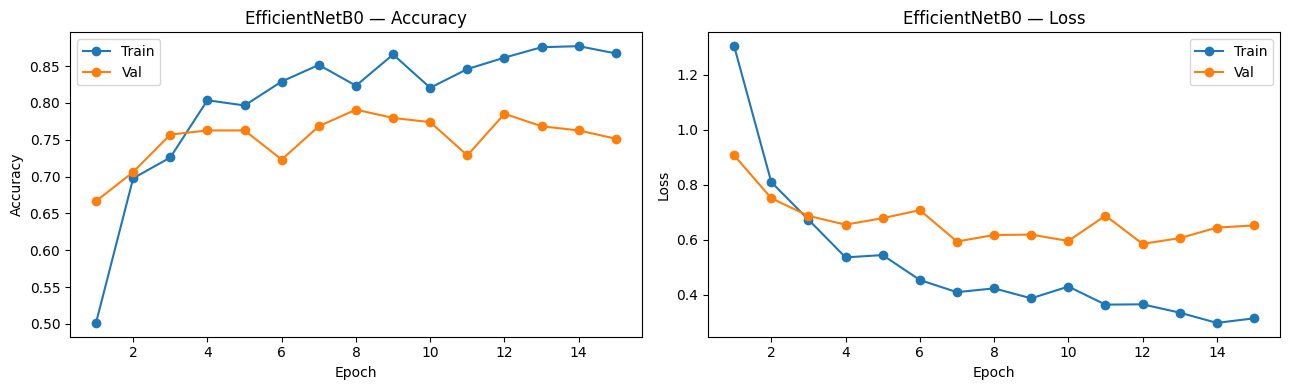

   Plot saved → /content/solar_panel_project/outputs/plots/efficientnet_history.png
✅ EfficientNetB0 (base) saved → /content/solar_panel_project/outputs/models/efficientnetb0_base.h5


In [14]:
def preprocess_dataset_for_efficientnet(ds):
    """
    EfficientNet expects pixel values in [-1, 1] (via effnet_preprocess_input).
    We collect all batches into two tensors so the tuner can also use them.
    Returns (images_tensor, labels_tensor).
    """
    all_images, all_labels = [], []
    for images, labels in ds:
        all_images.append(effnet_preprocess_input(images))  # applies EfficientNet normalisation
        all_labels.append(labels)
    return tf.concat(all_images, axis=0), tf.concat(all_labels, axis=0)


def build_efficientnet(num_classes: int,
                       img_h: int = 224,
                       img_w: int = 224,
                       rotation: float = 0.1,
                       zoom: float = 0.1,
                       dropout: float = 0.3,
                       dense_units: int = 128,
                       lr: float = 1e-3) -> tf.keras.Model:
    """
    EfficientNetB0 backbone (frozen) with a configurable head.
    Augmentation is applied on top; preprocess_input is assumed to have
    already been applied to the input tensors (see preprocess_dataset_for_efficientnet).
    """
    augment = tf.keras.Sequential([
        RandomFlip("horizontal"),
        RandomRotation(rotation),
        RandomZoom(zoom),
    ])

    base = EfficientNetB0(
        input_shape=(img_h, img_w, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # freeze backbone; only train the head

    model = tf.keras.models.Sequential([
        Input(shape=(img_h, img_w, 3)),
        augment,
        base,
        GlobalAveragePooling2D(),
        Dropout(dropout),
        Dense(dense_units, activation='relu'),
        Dense(num_classes, activation='softmax'),
    ], name="efficientnetb0_transfer")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Pre-process once and reuse across Phase 7 and Phase 8
print("⏳ Preprocessing datasets for EfficientNet...")
train_images, train_labels = preprocess_dataset_for_efficientnet(train_ds)
val_images,   val_labels   = preprocess_dataset_for_efficientnet(val_ds)
print(f"   train: {train_images.shape}  val: {val_images.shape}")

effnet_model = build_efficientnet(NUM_CLASSES)
effnet_model.summary()

print("\n🚀 Training EfficientNetB0 (15 epochs)...")
effnet_history = effnet_model.fit(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    batch_size=BATCH_SIZE,
    epochs=15,
    class_weight=CLASS_WEIGHTS,
)

plot_training_history(
    effnet_history,
    "EfficientNetB0",
    os.path.join(PLOTS_DIR, "efficientnet_history.png")
)

effnet_base_path = os.path.join(MODELS_DIR, "efficientnetb0_base.h5")
effnet_model.save(effnet_base_path)
print(f"✅ EfficientNetB0 (base) saved → {effnet_base_path}")

---
## Phase 8 — Hyperparameter Tuning (Keras Tuner)

In [15]:
import keras_tuner as kt

def build_tunable_model(hp) -> tf.keras.Model:
    """
    Keras Tuner model builder — exposes four hyperparameters:
      - rotation_factor  : augmentation rotation strength
      - zoom_factor      : augmentation zoom strength
      - dropout_rate     : dropout before the dense layer
      - dense_units      : size of the dense layer
      - learning_rate    : Adam initial LR (log scale)
    """
    rotation = hp.Float("rotation_factor", min_value=0.05, max_value=0.30, step=0.05)
    zoom     = hp.Float("zoom_factor",     min_value=0.05, max_value=0.30, step=0.05)
    dropout  = hp.Float("dropout_rate",    min_value=0.0,  max_value=0.50, step=0.10)
    units    = hp.Int(  "dense_units",     min_value=64,   max_value=512,  step=64)
    lr       = hp.Float("learning_rate",   min_value=1e-4, max_value=1e-2, sampling="log")

    return build_efficientnet(
        num_classes=NUM_CLASSES,
        rotation=rotation, zoom=zoom,
        dropout=dropout, dense_units=units, lr=lr
    )


# Random Search over 20 trials — enough to find a good region without
# exhaustive grid search.  Results land in /content/kt_dir/.
tuner = kt.RandomSearch(
    build_tunable_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='/content/kt_dir',
    project_name='solar_effnet_tune',
    overwrite=True
)

print("\n🔍 Starting hyperparameter search (20 trials × 20 epochs each)...")
tuner.search(
    train_images, train_labels,
    validation_data=(val_images, val_labels),
    batch_size=BATCH_SIZE,
    epochs=20,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)],
    class_weight=CLASS_WEIGHTS,
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n🏆 Best hyperparameters found:")
for k, v in best_hps.values.items():
    print(f"   {k}: {v}")

# Save best HPs as JSON so they survive a runtime reset
with open(os.path.join(OUTPUTS_DIR, "best_hyperparameters.json"), "w") as f:
    json.dump(best_hps.values, f, indent=2)
print("\n✅ Best HPs saved → best_hyperparameters.json")

Trial 20 Complete [00h 00m 56s]
val_accuracy: 0.7853107452392578

Best val_accuracy So Far: 0.8248587846755981
Total elapsed time: 00h 20m 15s

🏆 Best hyperparameters found:
   rotation_factor: 0.2
   zoom_factor: 0.1
   dropout_rate: 0.2
   dense_units: 256
   learning_rate: 0.0016630990718727652

✅ Best HPs saved → best_hyperparameters.json


---
## Phase 9 — Final Model Training + MLflow Logging

2026/05/04 12:44:31 INFO mlflow.tracking.fluent: Experiment with name 'solar_panel_defect_classification' does not exist. Creating a new experiment.


Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - accuracy: 0.5749 - loss: 1.1410 - val_accuracy: 0.6102 - val_loss: 0.9385 - learning_rate: 0.0017
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.7500 - loss: 0.6713 - val_accuracy: 0.7175 - val_loss: 0.8420 - learning_rate: 0.0017
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.7684 - loss: 0.5868 - val_accuracy: 0.7401 - val_loss: 0.7512 - learning_rate: 0.0017
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.8107 - loss: 0.4975 - val_accuracy: 0.7062 - val_loss: 0.8027 - learning_rate: 0.0017
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.8249 - loss: 0.4592 - val_accuracy: 0.7232 - val_loss: 0.7413 - learning_rate: 0.0017
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.8602 - loss: 0.3781 - val_accuracy: 0.7571 - val_loss: 0.7291 - learning_rate: 0.0017
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.8432 - loss: 0.3893 - 


✅ MLflow run complete. Best val accuracy: 0.8079
   Model artifact logged.
🏃 View run efficientnetb0_final at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/16/runs/3026ede0f7f641f1b52c3b7d75f1132c
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/16


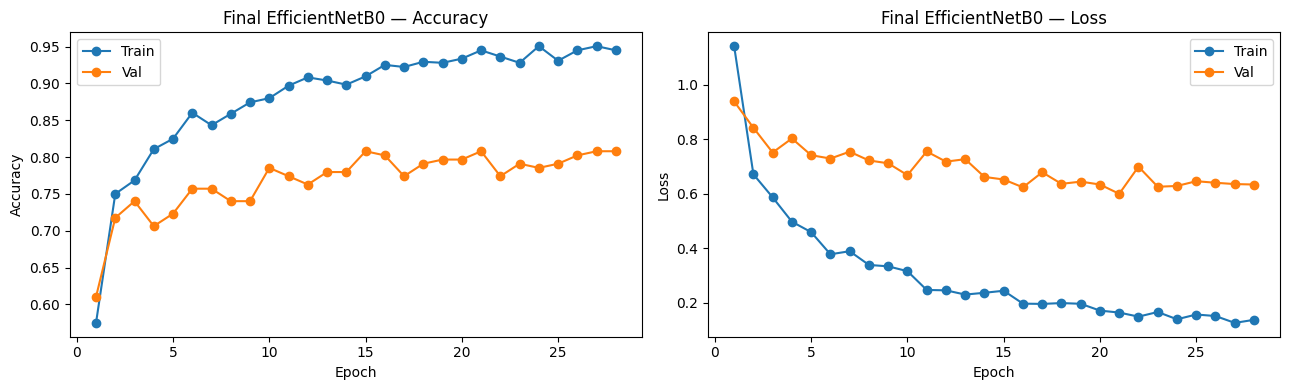

   Plot saved → /content/solar_panel_project/outputs/plots/final_model_history.png
✅ Final model saved → /content/solar_panel_project/outputs/models/trained_effnet_finetune.h5


In [16]:
def train_final_model_with_mlflow(
    best_hps,
    train_images, train_labels,
    val_images, val_labels,
    class_weights: dict,
    batch_size: int,
    experiment_name: str,
    save_path: str
) -> tuple:
    """
    Trains the best EfficientNetB0 configuration and logs everything to MLflow:
      - all hyperparameters
      - per-epoch accuracy & loss
      - the saved model artifact
    Returns (model, history).
    """
    mlflow.set_experiment(experiment_name)

    with mlflow.start_run(run_name="efficientnetb0_final"):
        # Log all best hyperparameters
        mlflow.log_params(best_hps.values)
        mlflow.log_params({
            "img_height":  IMG_HEIGHT,
            "img_width":   IMG_WIDTH,
            "batch_size":  batch_size,
            "val_split":   VAL_SPLIT,
            "num_classes": NUM_CLASSES,
        })

        # Build and train using best HPs
        model = build_efficientnet(
            num_classes=NUM_CLASSES,
            rotation=best_hps.get("rotation_factor"),
            zoom=best_hps.get("zoom_factor"),
            dropout=best_hps.get("dropout_rate"),
            dense_units=best_hps.get("dense_units"),
            lr=best_hps.get("learning_rate"),
        )

        history = model.fit(
            train_images, train_labels,
            validation_data=(val_images, val_labels),
            batch_size=batch_size,
            epochs=30,
            callbacks=make_callbacks(),
            class_weight=class_weights,
        )

        # Log scalar metrics at each epoch
        for epoch, (acc, val_acc, loss, val_loss) in enumerate(
            zip(
                history.history['accuracy'],
                history.history['val_accuracy'],
                history.history['loss'],
                history.history['val_loss'],
            ), start=1
        ):
            mlflow.log_metrics({
                "train_accuracy": acc,
                "val_accuracy":   val_acc,
                "train_loss":     loss,
                "val_loss":       val_loss,
            }, step=epoch)

        # Summary metrics
        best_val_acc = max(history.history['val_accuracy'])
        mlflow.log_metric("best_val_accuracy", best_val_acc)

        # Save model file then log as artifact
        model.save(save_path)
        mlflow.log_artifact(save_path, artifact_path="model")

        print(f"\n✅ MLflow run complete. Best val accuracy: {best_val_acc:.4f}")
        print(f"   Model artifact logged.")

    return model, history


FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "trained_effnet_finetune.h5")

final_model, final_history = train_final_model_with_mlflow(
    best_hps=best_hps,
    train_images=train_images,
    train_labels=train_labels,
    val_images=val_images,
    val_labels=val_labels,
    class_weights=CLASS_WEIGHTS,
    batch_size=BATCH_SIZE,
    experiment_name=EXPERIMENT_NAME,
    save_path=FINAL_MODEL_PATH,
)

plot_training_history(
    final_history,
    "Final EfficientNetB0",
    os.path.join(PLOTS_DIR, "final_model_history.png")
)

print(f"✅ Final model saved → {FINAL_MODEL_PATH}")

---
## Phase 10 — Model Evaluation & MongoDB Logging


📊 Classification Report:

                   precision    recall  f1-score   support

        Bird-drop       0.81      0.87      0.84        45
            Clean       0.63      0.85      0.72        34
            Dusty       0.84      0.63      0.72        43
Electrical-damage       0.86      0.75      0.80        16
  Physical-Damage       0.95      0.95      0.95        19
     Snow-Covered       1.00      0.90      0.95        20

         accuracy                           0.81       177
        macro avg       0.85      0.82      0.83       177
     weighted avg       0.82      0.81      0.81       177



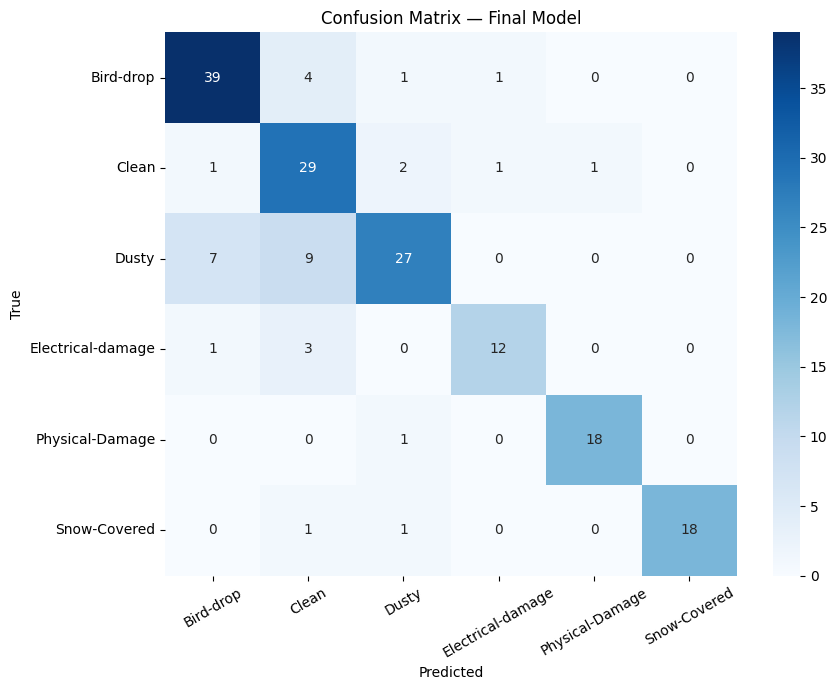


Overall Val Accuracy: 0.8079


/tmp/ipykernel_840/3093679586.py:69: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp":   datetime.datetime.utcnow().isoformat(),


✅ MongoDB record inserted (id: 69f8951e47135fb67820ba3f)
✅ Evaluation phase complete.


In [17]:
import datetime
from pymongo import MongoClient
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, val_images, val_labels, class_names: list, plots_dir: str) -> dict:
    """
    Evaluates the final model on the validation set.
    Generates and saves:
      - confusion matrix heatmap
      - per-class classification report
    Returns a dict of summary metrics.
    """
    # Get predictions
    y_pred_probs = model.predict(val_images, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = val_labels.numpy()

    # Overall accuracy
    overall_acc = np.mean(y_pred == y_true)

    # Classification report (per-class precision, recall, F1)
    report = classification_report(y_true, y_pred, target_names=class_names)
    print("\n📊 Classification Report:\n")
    print(report)

    # Save text report
    report_path = os.path.join(plots_dir, "classification_report.txt")
    with open(report_path, "w") as f:
        f.write(report)

    # Confusion matrix heatmap
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        cm, annot=True, fmt='d',
        xticklabels=class_names, yticklabels=class_names,
        cmap='Blues', ax=ax
    )
    ax.set_title("Confusion Matrix — Final Model")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.xticks(rotation=30)
    plt.tight_layout()
    cm_path = os.path.join(plots_dir, "confusion_matrix.png")
    plt.savefig(cm_path, dpi=150)
    plt.show()

    return {"overall_accuracy": float(overall_acc), "num_samples": int(len(y_true))}


def log_metrics_to_mongodb(metrics: dict, class_names: list, best_hps_values: dict):
    """
    Inserts an experiment record into the MongoDB collection
    'solar_panel_classification.experiments'.
    Connection string is read from the MONGO_DB_URL env variable.
    """
    mongo_url = os.environ.get('MONGO_DB_URL', '')
    if not mongo_url:
        print("⚠️  MONGO_DB_URL not set — skipping MongoDB logging.")
        return

    try:
        client = MongoClient(mongo_url, serverSelectionTimeoutMS=5000)
        db     = client["solar_panel_classification"]
        col    = db["experiments"]

        record = {
            "timestamp":   datetime.datetime.utcnow().isoformat(),
            "model":       "EfficientNetB0",
            "num_classes": len(class_names),
            "class_names": class_names,
            "best_hps":    best_hps_values,
            **metrics,
        }
        result = col.insert_one(record)
        print(f"✅ MongoDB record inserted (id: {result.inserted_id})")
    except Exception as exc:
        print(f"⚠️  MongoDB logging failed: {exc}")


# Run evaluation
eval_metrics = evaluate_model(final_model, val_images, val_labels, CLASS_NAMES, PLOTS_DIR)
print(f"\nOverall Val Accuracy: {eval_metrics['overall_accuracy']:.4f}")

# Persist evaluation metrics as JSON
with open(os.path.join(OUTPUTS_DIR, "eval_metrics.json"), "w") as f:
    json.dump(eval_metrics, f, indent=2)

# Log to MongoDB
log_metrics_to_mongodb(eval_metrics, CLASS_NAMES, best_hps.values)

print("✅ Evaluation phase complete.")

---
## Phase 11 — Save app.py (Streamlit Inference App)

In [18]:
APP_CODE = '''
import streamlit as st
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
from PIL import Image
import numpy as np
import json
import os

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Solar Panel Defect Classifier",
    page_icon="☀️",
    layout="centered"
)

st.title("☀️ Solar Panel Defect Classifier")
st.write("Upload a solar panel image to detect defects using EfficientNetB0.")

# ── Load class names from JSON if available ──────────────────────────────────
CLASS_NAMES_FILE = "class_names.json"
DEFAULT_CLASSES  = ["Bird-drop", "Clean", "Dusty",
                    "Electrical-damage", "Physical-damage", "Snow-Covered"]

if os.path.exists(CLASS_NAMES_FILE):
    with open(CLASS_NAMES_FILE) as f:
        CLASSES = json.load(f)
else:
    CLASSES = DEFAULT_CLASSES

# ── Model loading (cached so it only loads once per session) ──────────────────
@st.cache_resource
def load_model(model_path: str = "trained_effnet_finetune.h5"):
    """Load the saved Keras model. Cached to avoid reloading on every rerun."""
    return tf.keras.models.load_model(model_path)

with st.spinner("Loading model..."):
    model = load_model()

# ── Inference helper ──────────────────────────────────────────────────────────
def predict(image: Image.Image) -> np.ndarray:
    """Preprocess a PIL image and return softmax probability array."""
    img      = image.resize((224, 224)).convert("RGB")
    arr      = np.array(img, dtype=np.float32)
    arr      = np.expand_dims(arr, axis=0)   # add batch dimension
    arr      = preprocess_input(arr)         # EfficientNet normalisation
    return model.predict(arr, verbose=0)[0]  # drop batch dimension

# ── UI ────────────────────────────────────────────────────────────────────────
uploaded_file = st.file_uploader(
    "Upload a solar panel image", type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)

    with st.spinner("Analysing the panel..."):
        probs = predict(image)

    pred_idx   = int(np.argmax(probs))
    pred_class = CLASSES[pred_idx]
    confidence = probs[pred_idx]

    st.markdown(f"### Prediction: **{pred_class}**")
    st.markdown(f"**Confidence:** {confidence:.1%}")

    if pred_class == "Clean":
        st.success("The panel appears to be in good condition.")
    else:
        st.warning("A defect or contamination has been detected.")

    # Top-3 predictions
    st.write("### Top 3 Predictions")
    top3 = np.argsort(probs)[-3:][::-1]
    medals = ["🥇", "🥈", "🥉"]
    for rank, idx in enumerate(top3):
        st.write(f"{medals[rank]} **{CLASSES[idx]}** — {probs[idx]:.1%}")

    # Full probability table
    with st.expander("View all class probabilities"):
        for cls, prob in zip(CLASSES, probs):
            st.progress(float(prob), text=f"{cls}: {prob:.1%}")
'''

app_py_path = os.path.join(APP_DIR, "app.py")
with open(app_py_path, "w") as f:
    f.write(APP_CODE.strip())

print(f"✅ app.py saved → {app_py_path}")

# Also save a requirements.txt alongside the app
REQUIREMENTS = """tensorflow>=2.12
streamlit>=1.28
numpy
Pillow
"""
req_path = os.path.join(APP_DIR, "requirements.txt")
with open(req_path, "w") as f:
    f.write(REQUIREMENTS)
print(f"✅ requirements.txt saved → {req_path}")

✅ app.py saved → /content/solar_panel_project/app/app.py
✅ requirements.txt saved → /content/solar_panel_project/app/requirements.txt


---
## Phase 12 — Copy Final Model to App Dir & Zip All Outputs

In [20]:
import os
import zipfile
import shutil
from google.colab import files

def copy_final_model_to_app(model_path: str, app_dir: str):
    """
    The Streamlit app expects 'trained_effnet_finetune.h5' in its working directory.
    Copy the final model there so the app folder is self-contained.
    """
    dest = os.path.join(app_dir, "trained_effnet_finetune.h5")
    shutil.copy2(model_path, dest)
    print(f"   Model copied → {dest}")

    # Copy class_names.json too so the app can load it
    shutil.copy2(
        os.path.join(OUTPUTS_DIR, "class_names.json"),
        os.path.join(app_dir, "class_names.json")
    )
    print("   class_names.json copied → app/")


def zip_project_outputs(project_root: str, zip_name: str = "solar_panel_results.zip") -> str:
    """
    Zips the entire project outputs folder (models, plots, app, JSONs)
    into a single download-ready archive at /content/<zip_name>.
    Returns the path to the zip.
    """
    zip_path = f"/content/{zip_name}"
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, _, file_list in os.walk(project_root):
            # Skip the raw dataset to keep the zip manageable
            if "dataset" in root:
                continue
            for fname in file_list:
                full_path    = os.path.join(root, fname)
                archive_name = os.path.relpath(full_path, "/content")
                zf.write(full_path, archive_name)

    size_mb = os.path.getsize(zip_path) / 1e6
    print(f"✅ Zipped all outputs → {zip_path}  ({size_mb:.1f} MB)")
    return zip_path


# Copy model + class names to app folder
copy_final_model_to_app(FINAL_MODEL_PATH, APP_DIR)

# Build the zip archive
zip_path = zip_project_outputs(PROJECT_ROOT)

# Trigger browser download
files.download(zip_path)
print("\n📥 Download started — check your browser.")

   Model copied → /content/solar_panel_project/app/trained_effnet_finetune.h5
   class_names.json copied → app/
✅ Zipped all outputs → /content/solar_panel_results.zip  (68.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Download started — check your browser.


---
## Phase 13 — Summary

In [21]:
# Quick comparison table of all trained models

def summarise_all_models(histories: dict, class_names: list):
    """
    Prints a concise summary table of best val_accuracy per model.
    histories: {model_name: history.history dict}
    """
    print("\n" + "=" * 50)
    print(" Model Comparison Summary")
    print("=" * 50)
    print(f"  {'Model':<28}  {'Best Val Acc':>12}")
    print("-" * 50)
    for name, h in histories.items():
        best = max(h.get('val_accuracy', [0]))
        print(f"  {name:<28}  {best:>11.4f}")
    print("=" * 50)
    print(f"\n  Classes : {class_names}")
    print(f"  Final model saved : {FINAL_MODEL_PATH}")
    print(f"  App saved         : {os.path.join(APP_DIR, 'app.py')}")
    print(f"  Download zip      : {zip_path}")


all_histories = {
    "Baseline CNN":          baseline_history.history,
    "Improved CNN":          improved_history.history,
    "MobileNetV2":           mobilenet_history.history,
    "EfficientNetB0 (base)": effnet_history.history,
    "EfficientNetB0 (tuned)": final_history.history,
}

summarise_all_models(all_histories, CLASS_NAMES)

print("\n🎉 Pipeline complete!")


 Model Comparison Summary
  Model                         Best Val Acc
--------------------------------------------------
  Baseline CNN                       0.6328
  Improved CNN                       0.0904
  MobileNetV2                        0.7797
  EfficientNetB0 (base)              0.7910
  EfficientNetB0 (tuned)             0.8079

  Classes : ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
  Final model saved : /content/solar_panel_project/outputs/models/trained_effnet_finetune.h5
  App saved         : /content/solar_panel_project/app/app.py
  Download zip      : /content/solar_panel_results.zip

🎉 Pipeline complete!
